# <font color='green'>Non Clifford chapter</font>

In the last chapter, we built surface code memory experiments and simulated the performance of the surface code under varying levels of physical noise using `stim`. 

We also generated detector error models and constructed a minimum-weight perfect-matching decoder with `PyMatching`.
    
All of this was done with hundreds of thousands of shots for multiple code distances and physical error rates, which is already quite a sophisticated workflow. Yet, our laptop comfortably ran all these simulations without crashing. Did you wonder why?

The key reason is that everything we have done so far is built from Clifford operations acting on stabilizer states. The surface code itself is a stabilizer state. The noise we injected was described by Pauli channels that preserve the stabilizer structure. `stim` exploits this by using the stabilizer/tableau formalism. This was a concrete instance of the Gottesman–Knill theorem: Circuits composed solely of Clifford operations, acting on stabilizer states and measured in the Pauli bases, can be efficiently simulated on a classical computer.

In other words, our surface-code simulations were not performing classically hard quantum computation. They are extremely important for fault-tolerance and error correction, but from a computational-complexity perspective they live in a regime that is known to be classically simulable.



### <font color='red'>What comes next?</font>

In this chapter, we will pause the surface-code story and take a broader look at Clifford circuits and their classical simulation. 

To go beyond this “classically easy” regime, we need non-Clifford resources, such as T gates or suitable non-Pauli measurements. This chapter is about making that contrast very explicit. 

- We will formally introduce the Clifford group and briefly revisit the stabilizer formalism.


- We will see how the tableau representation used inside `stim` makes it possible to simulate very large Clifford circuits, such as 1D cluster states with tens of thousands of qubits.
- We will then contrast this with what happens when we add non-Clifford ingredients, such as T gates or certain types of measurements.

### <font color='red'>Clifford circuits</font>

The Pauli group on $n$ qubits is the set of $n$-fold tensor products of Pauli operators: $I, X, Y, Z$ with phases $\{\pm1, \pm i\}$.

The Clifford group on $n$ qubits is the set of unitary operators that preserve the Pauli group under conjugation: they map Pauli operators to Pauli operators. In other words, for a Clifford operator $C$ and a Pauli operator $P$, the conjugated operator $C P C^\dagger$ is still a Pauli operator. Common examples of Clifford gates include the Hadamard, Phase, and Controlled-NOT (CNOT) gates.

Some examples are: 

$C P C^\dagger = P'$

$H Z H = X$

$S X S^\dagger = Y$

$Z Y Z = -Y$

A Clifford circuit is a quantum circuit composed entirely of gates from the Clifford group. 

These circuits are not universal for quantum computation, but they have an important advantage that their evolution can be simulated in time polynomial in the number of qubits and gates on a classical computer.

This is precisely the regime exploited by `stim` in the previous chapter.


### <font color='red'>Stabilizer formalism</font>

A stabilizer state on $n$ qubits is a quantum state uniquely specified as the +1 common eigenstate of Pauli operators.

Think of a state $\ket{\psi}$. Instead of writing its whole amplitude vector of size $2^n$, we describe it by $n$ independent commuting Pauli operators 
$S_1, \ldots, S_n$
such that:

$S_i \ket{\psi} = \ket{\psi}$

Each $S_i$ is a tensor product of single-qubit Pauli matrices 
$I, X, Y, Z$ and a sign $\pm 1$: e.g. $𝑋_1Z_2X_3Z_4$ is one of the stabilizer of the state $\ket{\psi} = \ket{1010} + \ket{0101}$

Some famous examples are Bell states, GHZ states, Cluster states, and code states of many stabilizer error-correcting codes (including the surface code).

Instead of tracking a state vector of size $2^n$, we track these $n$ stabilizer generators, and update them under Clifford gates and Pauli measurements. That can be done in time polynomial in $n$, which is what makes stabilizer simulation efficient.


### <font color='red'>Representing clifford with Matrices: Tableau representation</font>

We can represent a Clifford operation on $n$ qubits as a $2n \times 2n$ unitary matrix and a $2n$ binary vector is called a Clifford tableau. 

Stabilizer format makes it easier to represent and manipulate Clifford operations.  Similary, tableau format makes it easier to represent and manipulate increasingly large Clifford circuits. 

We want a representation of Pauli operators that is easy to update with simple bit operations. The standard approach is:

For each qubit $j$, we encode the Pauli on that qubit by two bits $(x_j, z_j)$

$I \leftrightarrow (0,0)$

$X \leftrightarrow (1,0)$

$Z \leftrightarrow (0,1)$

$Y = iXZ \leftrightarrow (1,1)$

We also need one phase bit to store whether the overall operator is $+P$ or $-P$.

So a single 
$n$-qubit Pauli operator row is:

A phase bit $r \in \{0,1\}$ (0 = $+$, 1 = $-$)

$n$ X-bits: $(x_1, \ldots, x_n)$

$n$ Z-bits: $(z_1, \ldots, z_n)$

Total $1+2n$ bits per Pauli operator.

The full tableau is a binary matrix with $2n$ rows ($n$ “destabilizers” and $n$ “stabilizers”) and 
$2n+1$ columns ($n$ $X$ bits, $n$ $Z$ bits, 1 phase)

These rows are arranged into a binary matrix called the tableau: columns hold the $X$-bits, $Z$-bits, and phase bit; rows hold the stabilizer generators (and often an additional set of “destabilizers” that make measurements easy)

A typical starting point is $|0\rangle^{\otimes n}$, whose stabilizers are 
$Z_1, \ldots, Z_n$ and destabilizers 
$X_1, \ldots, X_n$, all encoded in the tableau.

This way, the tableau always encodes the post-measurement stabilizer state, and the whole simulation remains efficient in the number of qubits. 

The key point is that applying a Clifford gate corresponds to simple bit operations on this matrix. This is what `stim` does under the hood: the tableau always encodes the current stabilizer state, and every operation is an $O(n)$ or 
$O(n^2)$ update.


### <font color='red'>Cluster States as a Clifford Benchmark</font>

In this section, we will construct a 1D cluster state in `stim` and measure one of its stabilizers. 
We will benchmark how long it takes to estimate the expectation value of the stabilizer using both the analytic tableau simulator and the sampled estimator of `stim`.

A 1D cluster state on $(n)$ qubits is constructed as follows:

1. Start with all qubits in $(|0\rangle)$.
2. Apply a Hadamard gate $(H)$ to each qubit to create $(|+\rangle^{\otimes n})$.
3. Apply a controlled-Z (CZ) gate between each pair of neighbors:
   $((0,1), (1,2), \ldots, (n-2, n-1))$.

The result is a highly entangled stabilizer state. Cluster states form the
resource for measurement-based quantum computation (MBQC).

Even though MBQC can be universal when we allow adaptive and non-Clifford
measurements, the state itself is still a stabilizer state and therefore
admits an efficient classical description and simulation.

We’ll construct a 1D cluster state in `stim` and measure one of its stabilizers, for example $K_0 = X_0 Z_1,$ which has expectation value $\langle K_0 \rangle = 1$ on the cluster state. We will benchmark how long it takes to estimate $\langle K_0 \rangle$ for increasingly large systems.

## <font color='blue'>Cluster state simulations with `stim`</font>

In the rest of the chapter, we will simulate a cluster state with `stim` for variable numbers of qubits and see the effect of adding non-Clifford gates. 

In [22]:
import stim
import numpy as np
import matplotlib.pyplot as plotter
from noncliffordutility import *
import warnings
warnings.filterwarnings("ignore")

First sanity check, we will check the analytic estimates of $\langle K_0 \rangle$ for small values of $n$.

In [15]:
for n in [4, 10]:
    analytic = tableau_simulator_expectation_K0(n_qubits=n)
    print(f"n={n:2d}  analytic <K0>={analytic:+.3f}")

n= 4  analytic <K0>=+1.000
n=10  analytic <K0>=+1.000


We now use the cluster state as a *benchmark* to demonstrate the efficiency of Clifford simulation with Stim.

We will fix a set of system sizes, e.g., $(n = 10, 100, 1000, 10\,000)$ qubits.
For each $(n)$, we will measure the time it takes to compute an estimate of $\langle K_0 \rangle$ using `stim`'s tableau-based `compile_sampler()`.




In [16]:
shots = 1
n_list_stim = [100, 250, 500, 750, 1000, 1500, 2000, 3500, 5000, 7500, 10_000 ]
n_list_stim, t_comp, exps_stim = run_stim_sweep(
    n_list_stim, shots=shots
    )

[STIM] n_qubits=   100  t_compile=8.007e-04 s  <X0Z1>=+1.000000  
[STIM] n_qubits=   250  t_compile=1.143e-03 s  <X0Z1>=+1.000000  
[STIM] n_qubits=   500  t_compile=1.329e-03 s  <X0Z1>=+1.000000  
[STIM] n_qubits=   750  t_compile=2.356e-03 s  <X0Z1>=+1.000000  
[STIM] n_qubits=  1000  t_compile=6.172e-04 s  <X0Z1>=+1.000000  
[STIM] n_qubits=  1500  t_compile=2.529e-03 s  <X0Z1>=+1.000000  
[STIM] n_qubits=  2000  t_compile=2.712e-03 s  <X0Z1>=+1.000000  
[STIM] n_qubits=  3500  t_compile=7.747e-03 s  <X0Z1>=+1.000000  
[STIM] n_qubits=  5000  t_compile=1.822e-02 s  <X0Z1>=+1.000000  
[STIM] n_qubits=  7500  t_compile=3.777e-02 s  <X0Z1>=+1.000000  
[STIM] n_qubits= 10000  t_compile=7.165e-02 s  <X0Z1>=+1.000000  


Now we plot the results.

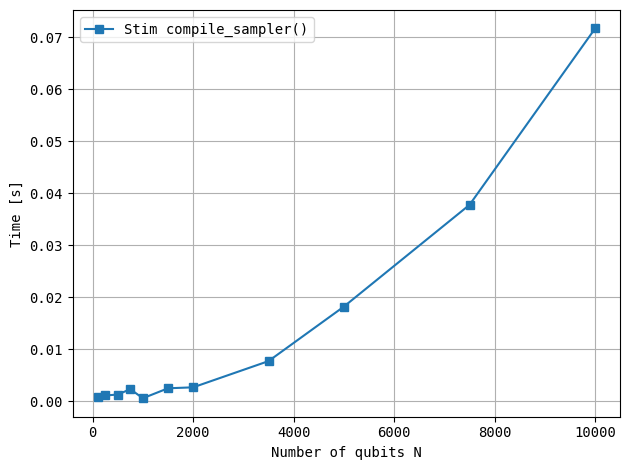

In [17]:
plotter.plot(n_list_stim, t_comp, "s-", label="Stim compile_sampler()")
plotter.xlabel("Number of qubits N")
plotter.ylabel("Time [s]")
plotter.grid(True)
plotter.legend()
plotter.tight_layout() 

In [18]:
coeffs = np.polyfit(n_list_stim, t_comp, deg=2)
a, b, c = coeffs
print(f"Stim compile_sampler():  T(N) ≈ {a:.3e} N^2 + {b:.3e} N + {c:.3e}")


Stim compile_sampler():  T(N) ≈ 7.757e-10 N^2 + -7.853e-07 N + 1.424e-03


We see that the sampling-based estimation with 100,000 shots remains manageable for large $n$. The fitted curve shows that the runtime scales polynomially with $n$.


### <font color='red'>Putting it all together</font>

From the cluster-state benchmark, we see that using the tableau / stabilizer representation, Stim can simulate
very large Clifford circuits (e.g., 10,000 qubits) efficiently. 
All of this is possible because the circuit is entirely Clifford and the state is a stabilizer state.

This is a practical illustration of the Gottesman–Knill theorem.

## <font color='blue'>Adding non Cliffords</font>

Now, we will add non-Clifford gates to the mix using `cirq` and keep track of the time it takes to estimate the expectation value of the stabilizer.

A standard way to make Clifford circuits universal is to add a single-qubit T gate:

$T = \begin{pmatrix}
1 & 0 \\
0 & e^{i\pi/4}
\end{pmatrix}$

T is not a Clifford gate; it does not map Pauli operators to Pauli operators under conjugation. As soon as we sprinkle T gates into our circuit, the stabilizer structure is broken.

In [19]:
qc = make_1d_cluster_with_T_cirq(n = 10, add_T=True)
print(qc[0])

0: ───H───@───T───────────────────────────────────
          │
1: ───H───@───@───T───────────────────────────────
              │
2: ───H───────@───@───T───────────────────────────
                  │
3: ───H───────────@───@───T───────────────────────
                      │
4: ───H───────────────@───@───T───────────────────
                          │
5: ───H───────────────────@───@───T───────────────
                              │
6: ───H───────────────────────@───@───T───────────
                                  │
7: ───H───────────────────────────@───@───T───────
                                      │
8: ───H───────────────────────────────@───@───T───
                                          │
9: ───H───────────────────────────────────@───T───


Now we will compare the time it takes to estimate the expectation value of the stabilizer using `stim` and after adding T gates to the circuit with `cirq`.

In [20]:
n_list_stim = [4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]
n_list_stim, t_comp, exps_stim = run_stim_sweep(
    n_list_stim,
)

n_list_cirq = [4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]  # adjust if your machine can handle more
(
n_list_cirq,
t_exact_cirq,
exps_exact_cirq,
) = run_cirq_T_sweep(n_list_cirq)

[STIM] n_qubits=     4  t_compile=3.521e-04 s  <X0Z1>=+1.000000  
[STIM] n_qubits=     6  t_compile=1.608e-04 s  <X0Z1>=+1.000000  
[STIM] n_qubits=     8  t_compile=1.382e-04 s  <X0Z1>=+1.000000  
[STIM] n_qubits=    10  t_compile=3.982e-04 s  <X0Z1>=+1.000000  
[STIM] n_qubits=    12  t_compile=1.311e-04 s  <X0Z1>=+1.000000  
[STIM] n_qubits=    14  t_compile=1.309e-04 s  <X0Z1>=+1.000000  
[STIM] n_qubits=    16  t_compile=1.455e-04 s  <X0Z1>=+1.000000  
[STIM] n_qubits=    18  t_compile=1.296e-04 s  <X0Z1>=+1.000000  
[STIM] n_qubits=    20  t_compile=1.388e-04 s  <X0Z1>=+1.000000  
[STIM] n_qubits=    22  t_compile=1.392e-04 s  <X0Z1>=+1.000000  
[STIM] n_qubits=    24  t_compile=1.399e-04 s  <X0Z1>=+1.000000  
[STIM] n_qubits=    26  t_compile=1.336e-04 s  <X0Z1>=+1.000000  
[CIRQ+T] n_qubits=  4  t_sim=3.413e-03 s  <X0Z1>_sim=+0.707107  
[CIRQ+T] n_qubits=  6  t_sim=1.240e-03 s  <X0Z1>_sim=+0.707107  
[CIRQ+T] n_qubits=  8  t_sim=1.563e-03 s  <X0Z1>_sim=+0.707107  
[CIRQ+T] n_qu

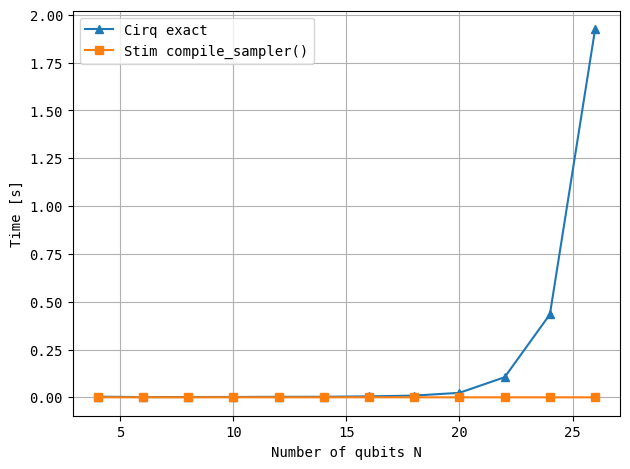

In [21]:
plotter.figure()
plotter.plot(n_list_cirq, t_exact_cirq, "^-", label=f"Cirq exact")
plotter.plot(n_list_stim, t_comp, "s-", label="Stim compile_sampler()")
plotter.xlabel("Number of qubits N")
plotter.ylabel("Time [s]")
plotter.grid(True)
plotter.legend()
plotter.tight_layout()    

In summary, we saw that Clifford circuits remain classically tractable and that adding a modest number of non-Clifford gates pushes us into a regime where classical simulation becomes expensive, and we expect genuinely quantum computational power.

In a fault-tolerant setting, though, we don’t apply these gates directly to bare physical qubits: we implement them as logical operations on encoded qubits. In the next chapter, we focus on how these logical Clifford operations are actually realized in surface-code architectures.

